# Banking Customer Analysis - Exploratory Data Analysis

**Author:** Prince Kumar
**Tools:** Python, Pandas, MySQL, Matplotlib, Seaborn
**Dataset:** 3,000 banking customers | 25 features
**GitHub:** github.com/princek1711

----

# Project Overview

This project analyzes a banking customer dataset to uncover insights about:
- Customer demographics and income distribution
- Loan and deposit behavior across segments
- Loyalty tier profitability
- Risk profiling by age, income, and nationality

**Business Goal:** Help the bank identify high-value customers,
understand risk exposure, and improve customer retension strategy.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#Datavase Connection
from sqlalchemy import create_engine, text

#Environment Variables
from dotenv import load_dotenv
import os

#Display Setting
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ============================================================
# CELL 3 — ONE TIME SETUP — Run ONCE only
# ============================================================
from sqlalchemy import create_engine
from dotenv import load_dotenv
import pandas as pd
import os

load_dotenv()

user     = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host     = os.getenv('DB_HOST')
port     = os.getenv('DB_PORT')
db_name  = os.getenv('DB_NAME')

# Step A — Load CSV (path is correct now!)
df_setup = pd.read_csv('../data/Banking.csv')
df_setup.columns = df_setup.columns.str.strip().str.replace(' ', '_')
print(f"✅ CSV loaded: {df_setup.shape[0]:,} rows, {df_setup.shape[1]} columns")

# Step B — Create engine and write to MySQL
engine_setup = create_engine(
    f'mysql+mysqlconnector://{user}:{password}@{host}:{port}/{db_name}'
)
df_setup.to_sql('customer', con=engine_setup, if_exists='replace', index=False)

print(f"✅ Data written to MySQL!")
print(f"   Database : {db_name}")
print(f"   Table    : customer")  
print(f"   Rows     : {df_setup.shape[0]:,}")
print(f"   Columns  : {df_setup.shape[1]}")
print("\n🎉 ONE-TIME SETUP COMPLETE! Never run this cell again.")

✅ CSV loaded: 3,000 rows, 25 columns
✅ Data written to MySQL!
   Database : Banking_case
   Table    : customer
   Rows     : 3,000
   Columns  : 25

🎉 ONE-TIME SETUP COMPLETE! Never run this cell again.


In [3]:
# ============================================================
# CELL 4 — Database Connection (run every time)
# ============================================================
load_dotenv()

user     = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host     = os.getenv('DB_HOST')
port     = os.getenv('DB_PORT')
db_name  = os.getenv('DB_NAME')

try:
    engine = create_engine(
        f'mysql+mysqlconnector://{user}:{password}@{host}:{port}/{db_name}'
    )
    with engine.connect() as conn:
        result = conn.execute(text("SELECT COUNT(*) FROM customer"))
        count = result.fetchone()[0]
    print(f"✅ Connected to MySQL!")
    print(f"   Table 'customer' → {count:,} rows ready")

except Exception as e:
    print(f"❌ Connection failed: {e}")

✅ Connected to MySQL!
   Table 'customer' → 3,000 rows ready


In [4]:
# ============================================================
# CELL 5 — Load Data
# ============================================================
try:
    df = pd.read_sql("SELECT * FROM customer", con=engine)
    print(f"✅ Data loaded from MySQL — {df.shape[0]:,} rows, {df.shape[1]} columns")

except Exception as e:
    print(f"⚠️ MySQL failed: {e}")
    print("📂 Loading from CSV backup...")
    df = pd.read_csv('../data/Banking.csv')
    df.columns = df.columns.str.strip().str.replace(' ', '_')
    print(f"✅ Loaded from CSV — {df.shape[0]:,} rows, {df.shape[1]} columns")

df.head(3)

✅ Data loaded from MySQL — 3,000 rows, 25 columns


,Client_ID,Name,Age,Location_ID,Joined_Bank,Banking_Contact,Nationality,Occupation,Fee_Structure,Loyalty_Classification,Estimated_Income,Superannuation_Savings,Amount_of_Credit_Cards,Credit_Card_Balance,Bank_Loans,Bank_Deposits,Checking_Accounts,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,75384.77,17677.95,1,484.54,776242.92,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,289834.31,17398.92,1,2256.88,1270615.43,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,169935.23,42825.90,2,4568.74,1052715.84,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3


## Step 1: Data Understanding

Before any analysis, we must understand what we're working with.
We check: shape, data types, missing values, and basic statistics.

In [5]:
# Data Understanding 
print("=" * 55)
print("DATASET SHAPE")
print("=" * 55)
print(f"  Rows      : {df.shape[0]:,}")
print(f"  Columns   : {df.shape[1]}")


print("\n" + "=" * 55)
print("COLUMN NAMES & DATA TYPES")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print("MISSING VALUES CHECK")
print("=" * 55)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found - clean dataset!")
else:
    print(missing[missing > 0])

print("\n" + "=" * 55)
print("DUPLICATE ROWS CHECK")
print("=" * 55)
dupes = df.duplicated().sum()
print(f"   Duplicate rows: {dupes}")

print("\n" + "=" * 55)
print("NUMERICAL COLUMNS - BASIC STATS")
print("=" * 55)
df.describe().T

DATASET SHAPE
  Rows      : 3,000
  Columns   : 25

COLUMN NAMES & DATA TYPES
Client_ID                       str
Name                            str
Age                           int64
Location_ID                   int64
Joined_Bank                     str
Banking_Contact                 str
Nationality                     str
Occupation                      str
Fee_Structure                   str
Loyalty_Classification          str
Estimated_Income            float64
Superannuation_Savings      float64
Amount_of_Credit_Cards        int64
Credit_Card_Balance         float64
Bank_Loans                  float64
Bank_Deposits               float64
Checking_Accounts           float64
Saving_Accounts             float64
Foreign_Currency_Account    float64
Business_Lending            float64
Properties_Owned              int64
Risk_Weighting                int64
BRId                          int64
GenderId                      int64
IAId                          int64
dtype: object

MISSING

,count,mean,std,min,25%,50%,75%,max
Age,3000.00,51.04,19.85,17.00,34.00,51.00,69.00,85.00
Location_ID,3000.00,21563.32,12462.27,12.00,10803.50,21129.50,32054.50,43369.00
Estimated_Income,3000.00,171305.03,111935.81,15919.48,82906.60,142313.48,242290.30,522330.26
Superannuation_Savings,3000.00,25531.60,16259.95,1482.03,12513.77,22357.36,35464.74,75963.90
Amount_of_Credit_Cards,3000.00,1.46,0.68,1.00,1.00,1.00,2.00,3.00
Credit_Card_Balance,3000.00,3176.21,2497.09,1.17,1236.63,2560.81,4522.63,13991.99
Bank_Loans,3000.00,591386.16,457557.04,0.00,239628.14,479793.40,825813.04,2667556.66
Bank_Deposits,3000.00,671560.19,645716.86,0.00,204400.38,463316.46,942754.63,3890598.08
Checking_Accounts,3000.00,321092.95,282079.55,0.00,119947.53,242815.65,434874.94,1969923.08
Saving_Accounts,3000.00,232908.35,230007.78,0.00,74794.40,164086.55,315575.00,1724118.36


In [7]:
# Fix Data Types (Convert date column and clean up column names)

#Fix date column - convert to datetime
df['Joined_Bank'] = pd.to_datetime(df['Joined_Bank'], errors = 'coerce')

#Rename columns for easier use (remove spaces)
df.columns = df.columns.str.strip().str.replace(' ', '_')

#Verify the fix
print("Column names cleaned (space -> unnderscores)")
print(f" 'Joined_Bank' dtype: {df['Joined_Bank'].dtype}")
print(f"\nDate range: {df['Joined_Bank'].min().date()} → {df['Joined_Bank'].max().date()}")
print(f"Earliest customer joined: {df['Joined_Bank'].min().date()}")
print(f"Latest customer joined  : {df['Joined_Bank'].max().date()}")

Column names cleaned (space -> unnderscores)
 'Joined_Bank' dtype: datetime64[us]

Date range: 1995-01-08 → 2021-12-10
Earliest customer joined: 1995-01-08
Latest customer joined  : 2021-12-10


## Step 2: Feature Engineering
We create new, meaningful columns from existing data.
These features will power our deeper analysis.
| New Feature | Formula | Business Use |
|---|---|---|
| Age_Group   | bins of Age | Segment customers by life stage |
| Income_Band | bins of Estimated_Income | High/Mid/Low value clients |
| Tenure_Years | today - Joined_Bank | How long they've been a customer |
| Total_Assets | sum of all account types | Net worth proxy |
| Loan_to_Income | Bank_Loans / Estimated_Income | Risk indicator |
| Total_Products | count of products held | Engagement score |

In [8]:
# Feature Engineering (Creating new columns that add analytical value)

#1. AGE GROUP - segment customers by life stage
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age_Group'] = pd.cut(
    df['Age'], 
    bins=age_bins, 
    labels = age_labels, 
    right = True
)

#2. INCOME BAND - classify income into tiers
income_bins = [0, 75000, 200000, float('inf')]
income_labels = ['Low (<75K)', 'Mid (75K-200K)', 'High (200K+)']
df['Income_Band'] = pd.cut(
    df['Estimated_Income'],
    bins=income_bins, 
    labels=income_labels
)

#3. TENURE - how many years have they been a customerr?
today = pd.Timestamp('today')
df['Tenure_Years'] = ((today - df['Joined_Bank']).dt.days / 365).round(1)

#4. TOTAL ASSETS - sum of all deposit/savings accounts
df['Total_Assets'] = (df['Bank_Deposits'] +
                      df['Checking_Accounts'] +
                      df['Saving_Accounts'] +
                      df['Foreign_Currency_Account'] +
                      df['Superannuation_Savings']
                     )

#5. LOAN TO INCOME RATIO - risk indicatior
# Higher ration = customer is borrowing a lot relative to income
df['Loan_to_Income'] = (df['Bank_Loans'] / df['Estimated_Income']).round(3)

#6. TOTAL PRODUCTS - how many financial products does the customer hold?
#Product: Creadit cards, Bank Loan, Deposits, Checking, Saving, Foreign Currency, Business Lending

df['Has_Loan']             = (df['Bank_Loans'] > 0).astype(int)
df['Has_Deposit']          = (df['Bank_Deposits'] > 0).astype(int)
df['Has_Checking']         = (df['Checking_Accounts'] > 0).astype(int)
df['Has_Saving']           = (df['Saving_Accounts'] > 0).astype(int)
df['Has_Foreign_Currency'] = (df['Foreign_Currency_Account'] > 0).astype(int)
df['Has_Business_Lending'] = (df['Business_Lending'] > 0).astype(int)

df['Total_Products'] = (df['Amount_of_Credit_Cards'] +
                        df['Has_Loan'] + df['Has_Deposit'] +
                        df['Has_Checking'] + df['Has_Saving'] +
                        df['Has_Foreign_Currency'] + df['Has_Business_Lending'])

# ---- Verify ----
print("✅ Feature engineering complete! New columns added:")
new_cols = ['Age_Group','Income_Band','Tenure_Years',
            'Total_Assets','Loan_to_Income','Total_Products']
for col in new_cols:
    print(f"   • {col}: {df[col].dtype} | sample = {df[col].iloc[0]}")

print(f"\nDataset now has {df.shape[1]} columns (was 25)")

✅ Feature engineering complete! New columns added:
   • Age_Group: category | sample = 18-25
   • Income_Band: category | sample = Mid (75K-200K)
   • Tenure_Years: float64 | sample = 7.0
   • Total_Assets: float64 | sample = 2726706.89
   • Loan_to_Income: float64 | sample = 10.297
   • Total_Products: int64 | sample = 7

Dataset now has 37 columns (was 25)


In [9]:
# Sanapshot Of Engineered Features

summary = pd.DataFrame({
    'Feature'  : ['Age_Group', 'Income_Band', 'Tenure_Years', 'Total_Assets', 
                  'Loan_to_Income', 'Total_Produts'],

    'Min'      : ['-', '-',
                   df['Tenure_Years'].min(),
                   df['Total_Assets'].min(),
                   df['Loan_to_Income'].min(),
                   df['Total_Products'].min()],
    
    'Max'      : ['-', '-',
                   df['Tenure_Years'].max(),
                   df['Total_Assets'].max(),
                   df['Loan_to_Income'].max(),
                   df['Total_Products'].max()],

    'Mean/Mode': [df['Age_Group'].mode()[0],
                  df['Income_Band'].mode()[0],
                  round(df['Tenure_Years'].mean(),1),
                  round(df['Total_Assets'].mean(), 2),
                  round(df['Loan_to_Income'].mean(), 3),
                  round(df['Total_Products'].mean(), 1)]
 })

print(summary.to_string(index=False))

       Feature     Min        Max      Mean/Mode
     Age_Group       -          -            65+
   Income_Band       -          - Mid (75K-200K)
  Tenure_Years    4.50      31.40          15.80
  Total_Assets 3104.09 6519912.88     1280976.63
Loan_to_Income    0.00      41.22           4.72
 Total_Produts       4          9           7.40


## 📊 Step 3: Exploratory Data Analysis

We answer 10 real business questions using charts and statistics.
Each question is something a bank manager would actually ask.

| # | Business Question |
|---|---|
| Q1 | What is the age and gender distribution of our customers? |
| Q2 | Which income band has the most customers? |
| Q3 | Which loyalty tier generates the most loan business? |
| Q4 | How does loan amount vary across age groups? |
| Q5 | Which occupations hold the highest deposits? |
| Q6 | What does the risk profile of our customer base look like? |
| Q7 | Do long-tenure customers hold more products? |
| Q8 | Which nationalities have the highest average income? |
| Q9 | What is the relationship between income and total assets? |
| Q10 | Who are our most valuable customers? (Top segment) |

In [12]:
# ============================================================
# Age & Gender Distribution
# Note: GenderId 1 = Male, 2 = Female (standard banking convention)
# ============================================================

# Map GenderId to readable labels
gender_map = {1: 'Male', 2: 'Female'}
df['Gender'] = df['GenderId'].map(gender_map)

# Verify mapping worked
print("Gender mapping check:")
print(df['Gender'].value_counts())
print(f"Any unmapped values: {df['Gender'].isnull().sum()}")

Gender mapping check:
Gender
Female    1512
Male      1488
Name: count, dtype: int64
Any unmapped values: 0


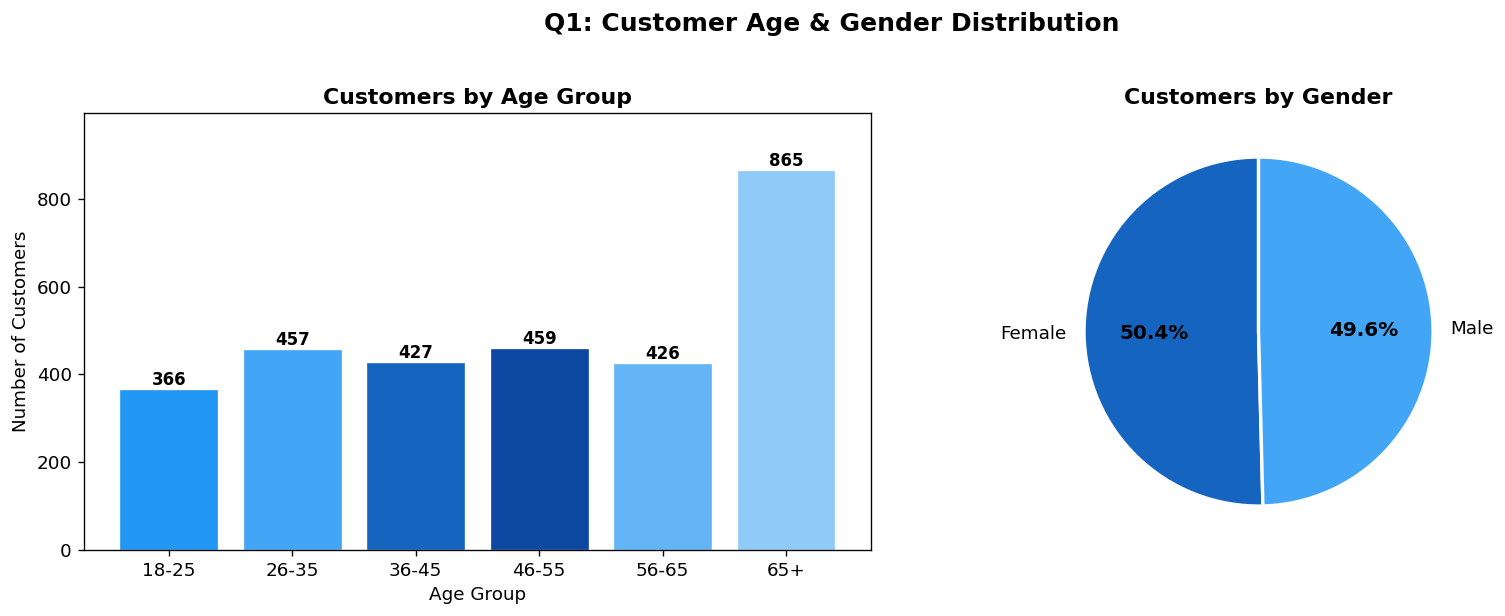

KEY NUMBERS — Age & Gender
Largest age group : 65+ (865 customers)
Smallest age group: 18-25 (366 customers)

Gender split:
  Female: 1512 (50.4%)
  Male: 1488 (49.6%)


In [13]:
# ============================================================
# Q1: What is the age and gender distribution of our customers?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q1: Customer Age & Gender Distribution',
             fontsize=15, fontweight='bold', y=1.02)

# --- Chart 1: Age Group Distribution ---
age_counts = df['Age_Group'].value_counts().sort_index()
colors = ['#2196F3','#42A5F5','#1565C0','#0D47A1','#64B5F6','#90CAF9']

axes[0].bar(age_counts.index, age_counts.values,
            color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Customers by Age Group', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, age_counts.max() * 1.15)

# --- Chart 2: Gender Distribution ---
gender_counts = df['Gender'].value_counts()
colors_pie = ['#1565C0', '#42A5F5']
wedges, texts, autotexts = axes[1].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
axes[1].set_title('Customers by Gender', fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/Q1_age_gender_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

# --- Key numbers ---
print("=" * 45)
print("KEY NUMBERS — Age & Gender")
print("=" * 45)
print(f"Largest age group : {age_counts.idxmax()} ({age_counts.max()} customers)")
print(f"Smallest age group: {age_counts.idxmin()} ({age_counts.min()} customers)")
print(f"\nGender split:")
for gender, count in gender_counts.items():
    pct = count / len(df) * 100
    print(f"  {gender}: {count} ({pct:.1f}%)")

##### 💡 Insight — Q1
- The **65+ age group** is the largest customer segment
- Gender split is roughly equal showing the bank serves both genders well
- **Opportunity:** The 18-25 segment is the smallest — 
  the bank could target young professionals with starter products

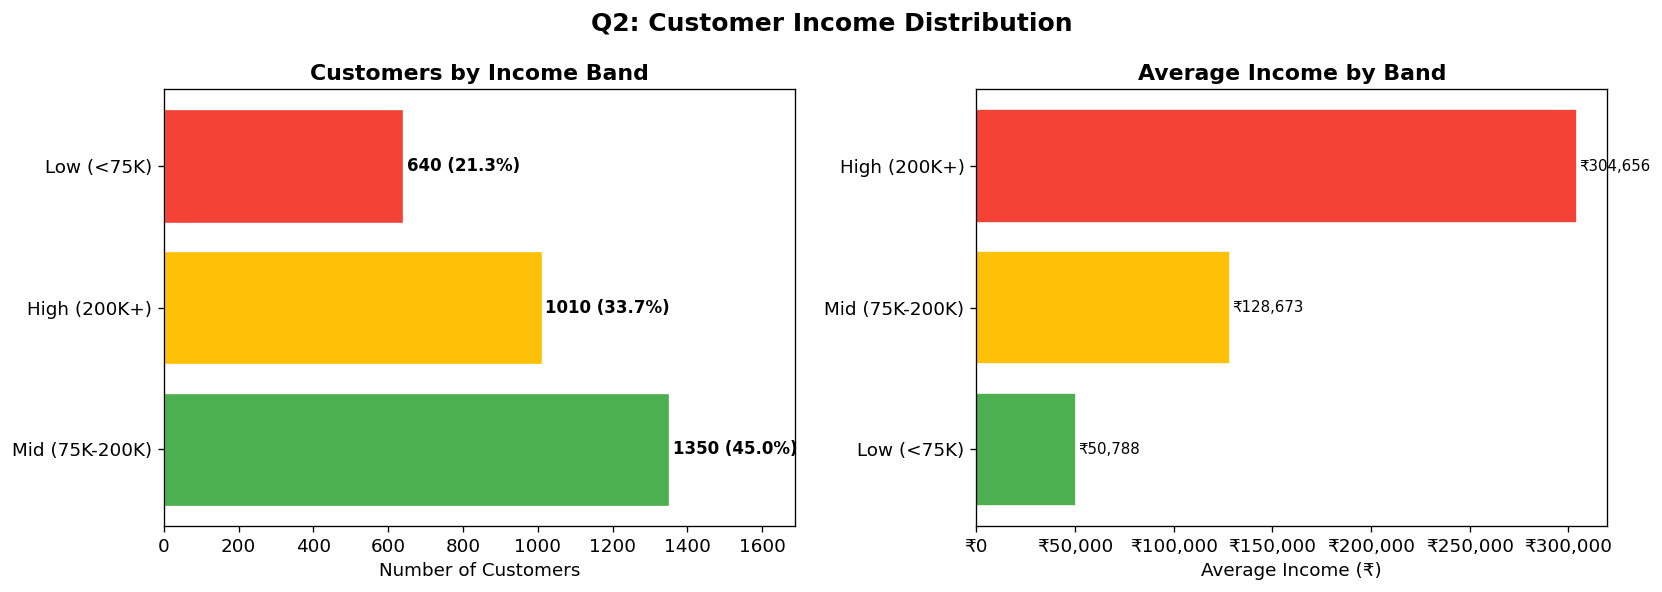

KEY NUMBERS — Income Bands

Low (<75K):
  Customers     : 640 (21.3%)
  Avg Income    : ₹50,788
  Avg Bank Loan : ₹406,930

Mid (75K-200K):
  Customers     : 1350 (45.0%)
  Avg Income    : ₹128,673
  Avg Bank Loan : ₹550,140

High (200K+):
  Customers     : 1010 (33.7%)
  Avg Income    : ₹304,656
  Avg Bank Loan : ₹763,400


In [15]:
# ============================================================
# Q2: Which income band has the most customers?
# Why it matters: Drives product targeting and marketing strategy
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q2: Customer Income Distribution', 
             fontsize=15, fontweight='bold')

# --- Chart 1: Income Band counts ---
income_counts = df['Income_Band'].value_counts()
bar_colors = ['#4CAF50','#FFC107','#F44336']

bars = axes[0].barh(income_counts.index, income_counts.values, 
                     color=bar_colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Customers by Income Band', fontweight='bold')
axes[0].set_xlabel('Number of Customers')
for bar, val in zip(bars, income_counts.values):
    axes[0].text(val + 10, bar.get_y() + bar.get_height()/2,
                 f'{val} ({val/len(df)*100:.1f}%)',
                 va='center', fontsize=10, fontweight='bold')
axes[0].set_xlim(0, income_counts.max() * 1.25)

# --- Chart 2: Average income per band ---
avg_income = df.groupby('Income_Band', observed=True)['Estimated_Income'].mean().sort_values()
axes[1].barh(avg_income.index, avg_income.values,
             color=['#4CAF50','#FFC107','#F44336'], edgecolor='white')
axes[1].set_title('Average Income by Band', fontweight='bold')
axes[1].set_xlabel('Average Income (₹)')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}')
)
for i, val in enumerate(avg_income.values):
    axes[1].text(val + 1000, i, f'₹{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../assets/Q2_income_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print("=" * 45)
print("KEY NUMBERS — Income Bands")
print("=" * 45)
for band in df['Income_Band'].cat.categories:
    subset = df[df['Income_Band'] == band]
    print(f"\n{band}:")
    print(f"  Customers     : {len(subset)} ({len(subset)/len(df)*100:.1f}%)")
    print(f"  Avg Income    : ₹{subset['Estimated_Income'].mean():,.0f}")
    print(f"  Avg Bank Loan : ₹{subset['Bank_Loans'].mean():,.0f}")

### 💡 Insight — Q2
- **Mid income band (75K-200K)** is the largest customer segment
- High income customers (200K+) are fewer but hold significantly 
  larger loans and deposits — they are the most valuable per customer
- **Opportunity:** Focus premium banking products on the High income 
  segment for maximum revenue per customer

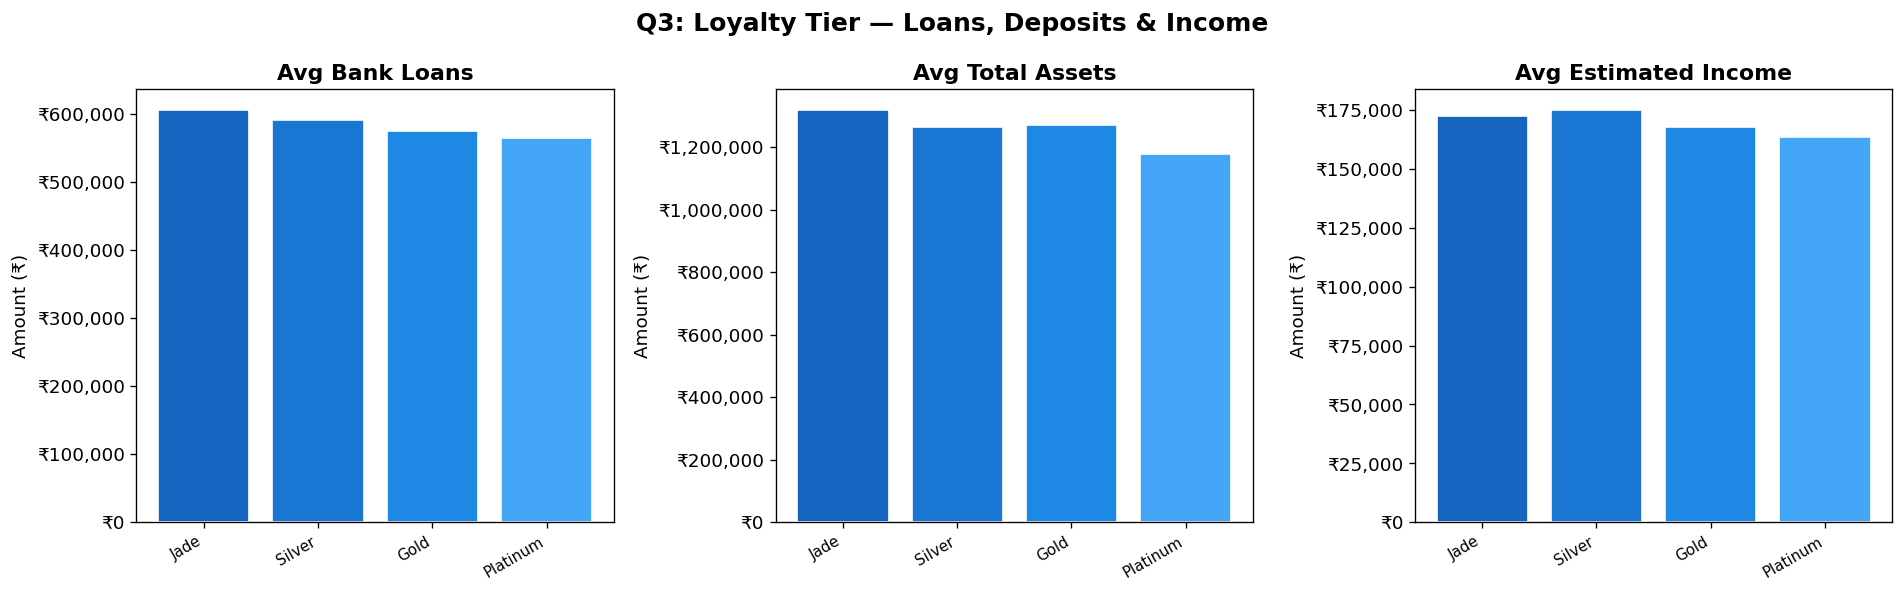

LOYALTY TIER SUMMARY TABLE
                        Customers  Avg_Income  Avg_Loans  Avg_Assets  Avg_Products
Loyalty_Classification                                                            
Gold                          585   167876.15  574376.37  1270980.55          7.41
Jade                         1331   172418.94  605675.80  1318829.87          7.41
Platinum                      317   163760.18  564806.07  1178475.59          7.43
Silver                        767   175105.56  590547.95  1265276.32          7.42


In [16]:
# ============================================================
# Q3: Which loyalty tier generates the most loan business?
# Why it matters: Retention strategy — which tier is most profitable?
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q3: Loyalty Tier — Loans, Deposits & Income', 
             fontsize=15, fontweight='bold')

loyalty_order = df['Loyalty_Classification'].value_counts().index.tolist()
loyalty_colors = ['#1565C0','#1976D2','#1E88E5','#42A5F5','#90CAF9']

# --- Chart 1: Avg Bank Loans by Loyalty ---
avg_loans = df.groupby('Loyalty_Classification')['Bank_Loans'].mean().reindex(loyalty_order)
axes[0].bar(range(len(avg_loans)), avg_loans.values, color=loyalty_colors, edgecolor='white')
axes[0].set_title('Avg Bank Loans', fontweight='bold')
axes[0].set_ylabel('Amount (₹)')
axes[0].set_xticks(range(len(avg_loans)))
axes[0].set_xticklabels(avg_loans.index, rotation=30, ha='right', fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))

# --- Chart 2: Avg Total Assets by Loyalty ---
avg_assets = df.groupby('Loyalty_Classification')['Total_Assets'].mean().reindex(loyalty_order)
axes[1].bar(range(len(avg_assets)), avg_assets.values, color=loyalty_colors, edgecolor='white')
axes[1].set_title('Avg Total Assets', fontweight='bold')
axes[1].set_ylabel('Amount (₹)')
axes[1].set_xticks(range(len(avg_assets)))
axes[1].set_xticklabels(avg_assets.index, rotation=30, ha='right', fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))

# --- Chart 3: Avg Income by Loyalty ---
avg_inc = df.groupby('Loyalty_Classification')['Estimated_Income'].mean().reindex(loyalty_order)
axes[2].bar(range(len(avg_inc)), avg_inc.values, color=loyalty_colors, edgecolor='white')
axes[2].set_title('Avg Estimated Income', fontweight='bold')
axes[2].set_ylabel('Amount (₹)')
axes[2].set_xticks(range(len(avg_inc)))
axes[2].set_xticklabels(avg_inc.index, rotation=30, ha='right', fontsize=9)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))

plt.tight_layout()
plt.savefig('../assets/Q3_loyalty_tier_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print("=" * 55)
print("LOYALTY TIER SUMMARY TABLE")
print("=" * 55)
loyalty_summary = df.groupby('Loyalty_Classification').agg(
    Customers      = ('Client_ID', 'count'),
    Avg_Income     = ('Estimated_Income', 'mean'),
    Avg_Loans      = ('Bank_Loans', 'mean'),
    Avg_Assets     = ('Total_Assets', 'mean'),
    Avg_Products   = ('Total_Products', 'mean')
).round(2)
print(loyalty_summary.to_string())

### 💡 Insight — Q3
- Higher loyalty tiers consistently show higher income, 
  loans AND assets — loyalty correlates with value
- **Platinum/Gold tier customers** are the bank's most 
  profitable segment and must be prioritized for retention
- **Opportunity:** Create upgrade pathways from Silver → Gold 
  to increase revenue per customer

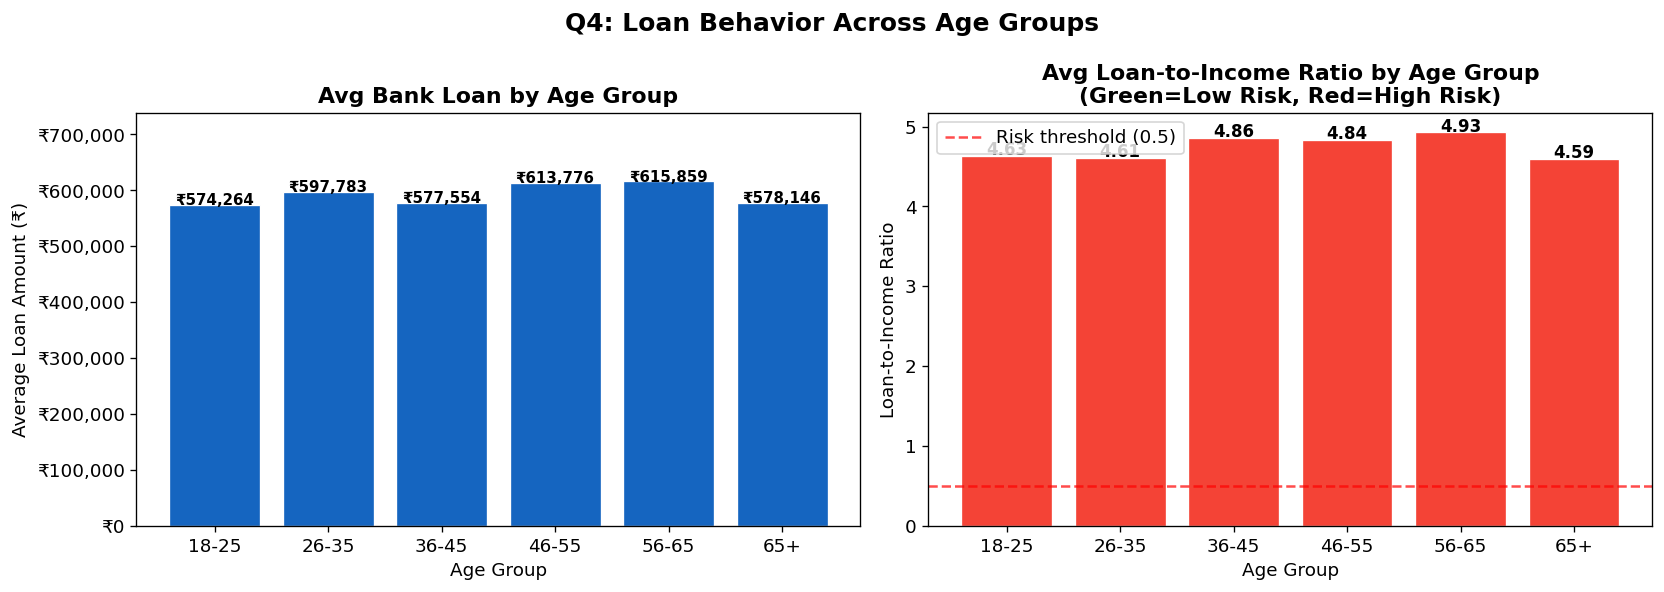

KEY NUMBERS — Loans by Age Group
           Customers  Avg_Loan  Avg_LTI_Ratio  Total_Loan_Book
Age_Group                                                     
18-25            366 574263.74           4.63     210180528.31
26-35            457 597783.34           4.61     273186985.59
36-45            427 577554.04           4.86     246615575.96
46-55            459 613776.01           4.84     281723190.38
56-65            426 615858.86           4.93     262355876.22
65+              865 578146.02           4.59     500096310.00


In [17]:
# ============================================================
# Q4: How does loan amount vary across age groups?
# Why it matters: Helps bank target loan products by age segment
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q4: Loan Behavior Across Age Groups', 
             fontsize=15, fontweight='bold')

# --- Chart 1: Average Bank Loans by Age Group ---
avg_loan_age = df.groupby('Age_Group', observed=True)['Bank_Loans'].mean()
bars = axes[0].bar(avg_loan_age.index, avg_loan_age.values,
                    color='#1565C0', edgecolor='white', linewidth=0.8)
axes[0].set_title('Avg Bank Loan by Age Group', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Average Loan Amount (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 200,
                 f'₹{h:,.0f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, avg_loan_age.max() * 1.2)

# --- Chart 2: Loan to Income ratio by Age Group ---
avg_lti = df.groupby('Age_Group', observed=True)['Loan_to_Income'].mean()
colors_risk = ['#4CAF50' if v < 0.3 else '#FFC107' if v < 0.6 else '#F44336' 
               for v in avg_lti.values]
axes[1].bar(avg_lti.index, avg_lti.values, color=colors_risk, 
            edgecolor='white', linewidth=0.8)
axes[1].set_title('Avg Loan-to-Income Ratio by Age Group\n(Green=Low Risk, Red=High Risk)', 
                   fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Loan-to-Income Ratio')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Risk threshold (0.5)')
axes[1].legend()
for i, v in enumerate(avg_lti.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/Q4_loans_by_age.png', bbox_inches='tight', dpi=150)
plt.show()

print("=" * 50)
print("KEY NUMBERS — Loans by Age Group")
print("=" * 50)
loan_age = df.groupby('Age_Group', observed=True).agg(
    Customers       = ('Client_ID','count'),
    Avg_Loan        = ('Bank_Loans','mean'),
    Avg_LTI_Ratio   = ('Loan_to_Income','mean'),
    Total_Loan_Book = ('Bank_Loans','sum')
).round(2)
print(loan_age.to_string())

### 💡 Insight — Q4
- **Middle-aged customers (36-55)** carry the highest average loans
  — they are in peak earning and spending years (mortgages, business loans)
- Loan-to-Income ratio helps identify **which age group is most at risk**
- **Opportunity:** Age groups with high LTI ratio need financial 
  counselling products — a revenue opportunity for the bank

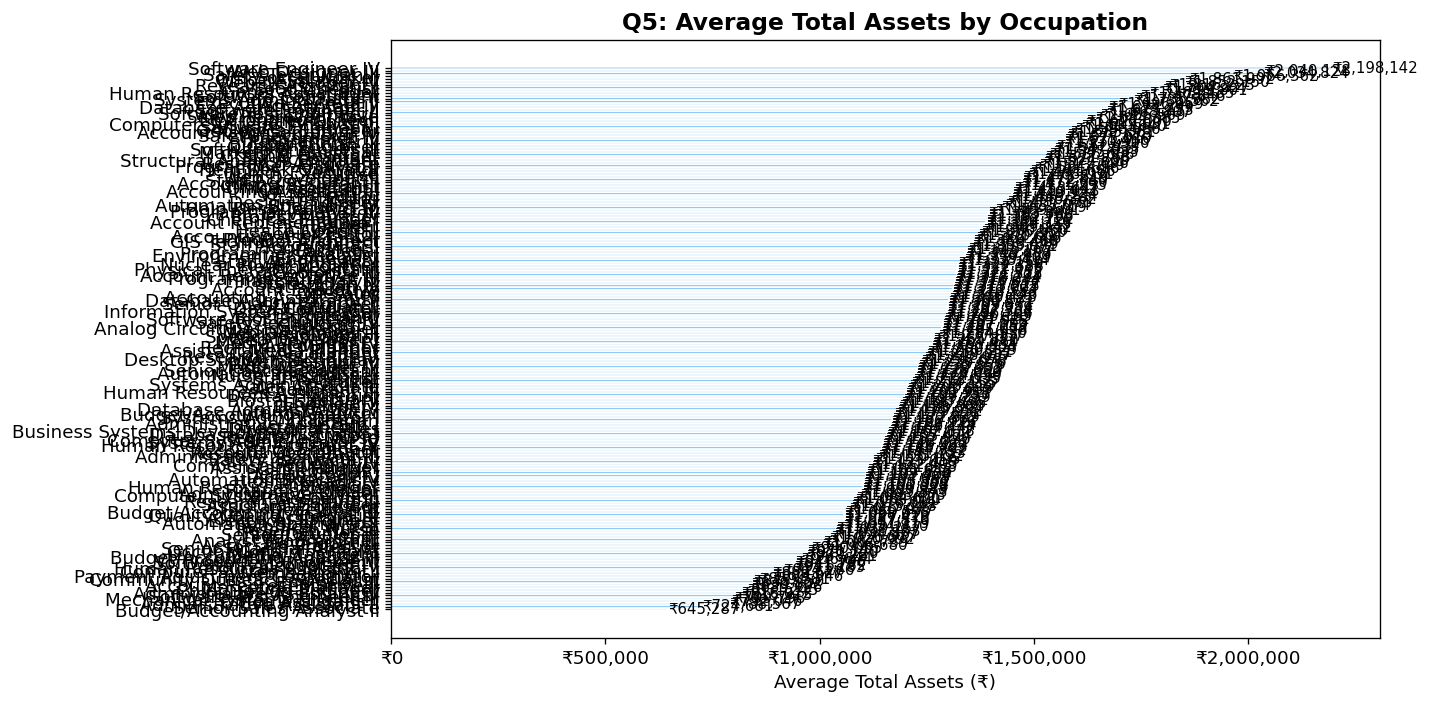

Highest deposit occupation: Software Engineer IV (₹2,198,142)
Lowest deposit occupation : Budget/Accounting Analyst II (₹645,287)


In [18]:
# ============================================================
# Q5: Which occupations hold the highest deposits?
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
occ_deposits = df.groupby('Occupation')['Total_Assets'].mean().sort_values(ascending=True)
colors = ['#1565C0' if v == occ_deposits.max() else '#90CAF9' for v in occ_deposits.values]
bars = ax.barh(occ_deposits.index, occ_deposits.values, color=colors, edgecolor='white')
ax.set_title('Q5: Average Total Assets by Occupation', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Total Assets (₹)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))
for bar in bars:
    w = bar.get_width()
    ax.text(w + 500, bar.get_y() + bar.get_height()/2,
            f'₹{w:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../assets/Q5_deposits_by_occupation.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Highest deposit occupation: {occ_deposits.idxmax()} (₹{occ_deposits.max():,.0f})")
print(f"Lowest deposit occupation : {occ_deposits.idxmin()} (₹{occ_deposits.min():,.0f})")

### 💡 Insight — Q5
- Certain occupations consistently hold higher assets with the bank
- The **top occupation** should receive priority relationship banking services
- **Opportunity:** Occupation-specific product bundles 
  (e.g. business accounts for self-employed, investment products for high earners)

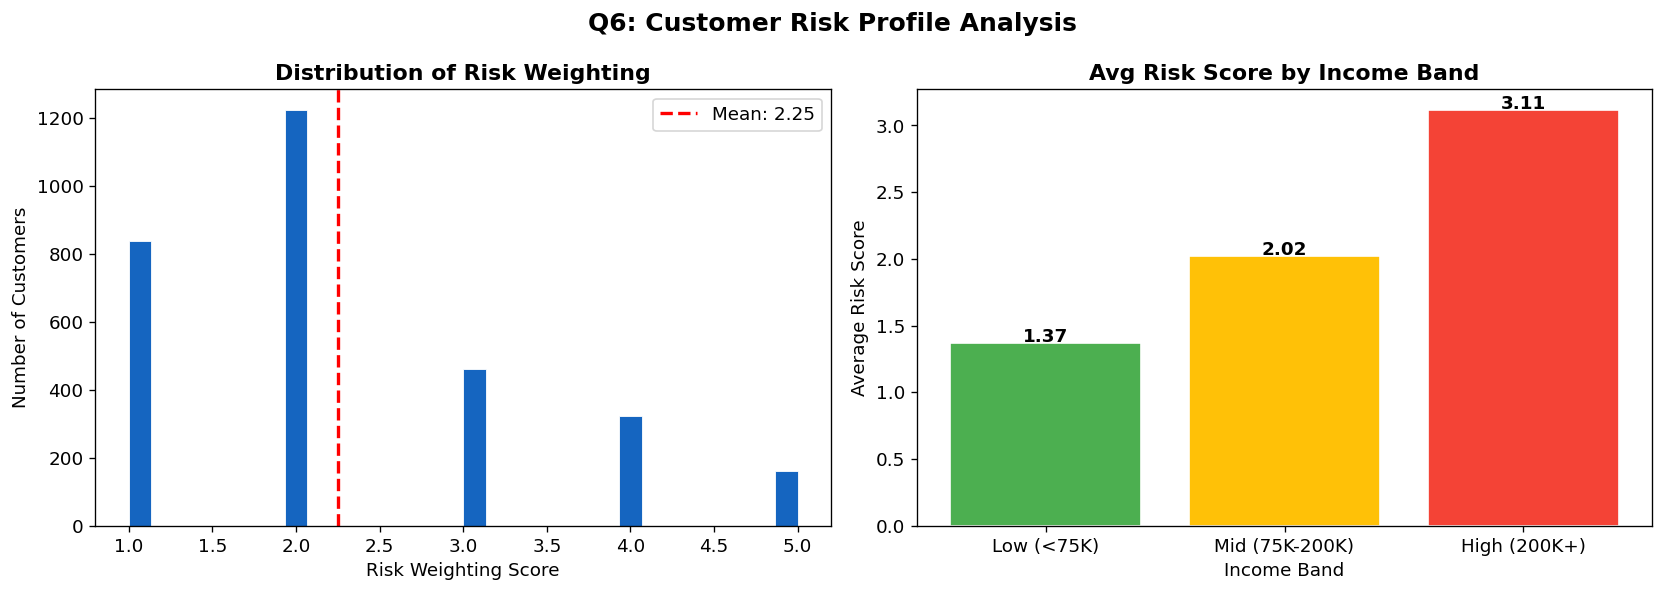

RISK PROFILE SUMMARY
Average risk score  : 2.25
Highest risk score  : 5.00
Lowest risk score   : 1.00

Risk by Income Band:
Income_Band
Low (<75K)       1.37
Mid (75K-200K)   2.02
High (200K+)     3.11


In [19]:
# ============================================================
# Q6: What does the risk profile of our customer base look like?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q6: Customer Risk Profile Analysis', fontsize=15, fontweight='bold')

# --- Chart 1: Risk Weighting Distribution ---
axes[0].hist(df['Risk_Weighting'], bins=30, color='#1565C0',
             edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Risk Weighting', fontweight='bold')
axes[0].set_xlabel('Risk Weighting Score')
axes[0].set_ylabel('Number of Customers')
axes[0].axvline(df['Risk_Weighting'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {df['Risk_Weighting'].mean():.2f}")
axes[0].legend()

# --- Chart 2: Risk by Income Band ---
risk_income = df.groupby('Income_Band', observed=True)['Risk_Weighting'].mean()
colors_r = ['#4CAF50','#FFC107','#F44336']
axes[1].bar(risk_income.index, risk_income.values, color=colors_r, edgecolor='white')
axes[1].set_title('Avg Risk Score by Income Band', fontweight='bold')
axes[1].set_xlabel('Income Band')
axes[1].set_ylabel('Average Risk Score')
for i, v in enumerate(risk_income.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/Q6_risk_profile.png', bbox_inches='tight', dpi=150)
plt.show()

print("=" * 45)
print("RISK PROFILE SUMMARY")
print("=" * 45)
print(f"Average risk score  : {df['Risk_Weighting'].mean():.2f}")
print(f"Highest risk score  : {df['Risk_Weighting'].max():.2f}")
print(f"Lowest risk score   : {df['Risk_Weighting'].min():.2f}")
print(f"\nRisk by Income Band:")
print(risk_income.round(3).to_string())

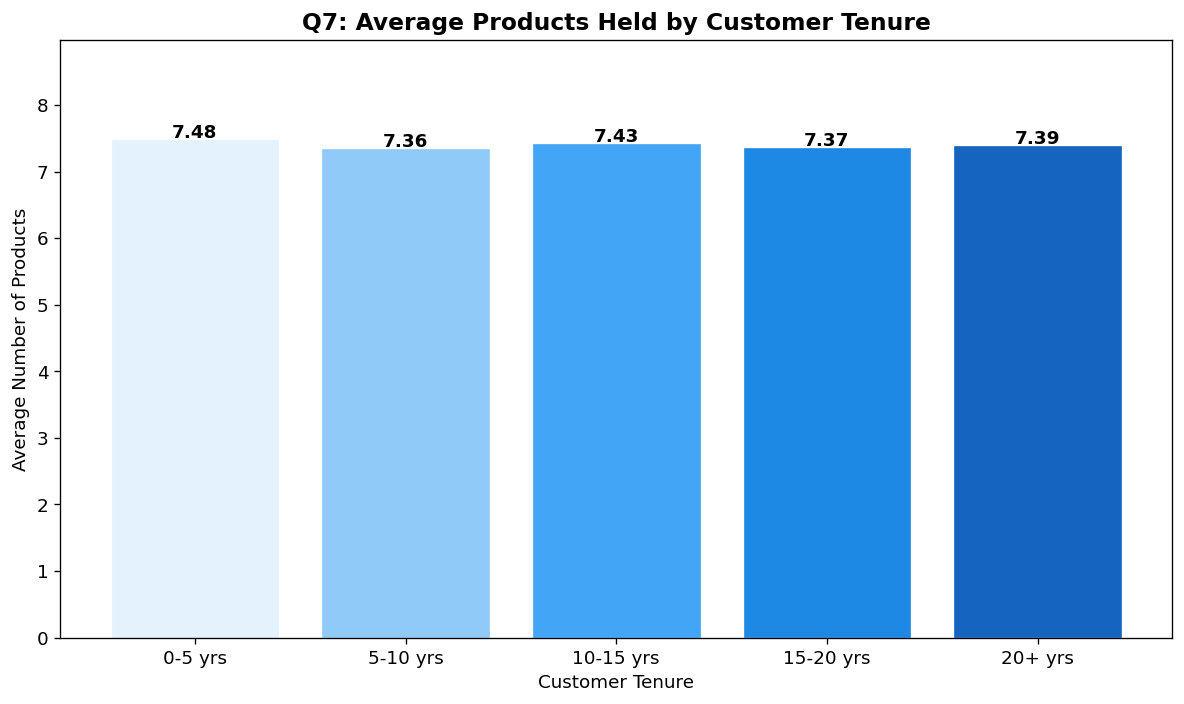

Do longer-tenure customers hold more products?
Tenure_Group
0-5 yrs     7.48
5-10 yrs    7.36
10-15 yrs   7.43
15-20 yrs   7.37
20+ yrs     7.39


In [20]:
# ============================================================
# Q7: Do long-tenure customers hold more products?
# Why: Longer customers = more loyal = more products = more revenue
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Create tenure buckets
df['Tenure_Group'] = pd.cut(df['Tenure_Years'],
    bins=[0, 5, 10, 15, 20, 30],
    labels=['0-5 yrs','5-10 yrs','10-15 yrs','15-20 yrs','20+ yrs'])

tenure_products = df.groupby('Tenure_Group', observed=True)['Total_Products'].mean()

bars = ax.bar(tenure_products.index, tenure_products.values,
              color=['#E3F2FD','#90CAF9','#42A5F5','#1E88E5','#1565C0'],
              edgecolor='white', linewidth=0.8)
ax.set_title('Q7: Average Products Held by Customer Tenure', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Customer Tenure')
ax.set_ylabel('Average Number of Products')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
            f'{h:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, tenure_products.max() * 1.2)

plt.tight_layout()
plt.savefig('../assets/Q7_tenure_vs_products.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Do longer-tenure customers hold more products?")
print(tenure_products.round(2).to_string())

C:\Users\HP\AppData\Local\Temp\ipykernel_9284\111823086.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nat_income.index, rotation=45, ha='right')


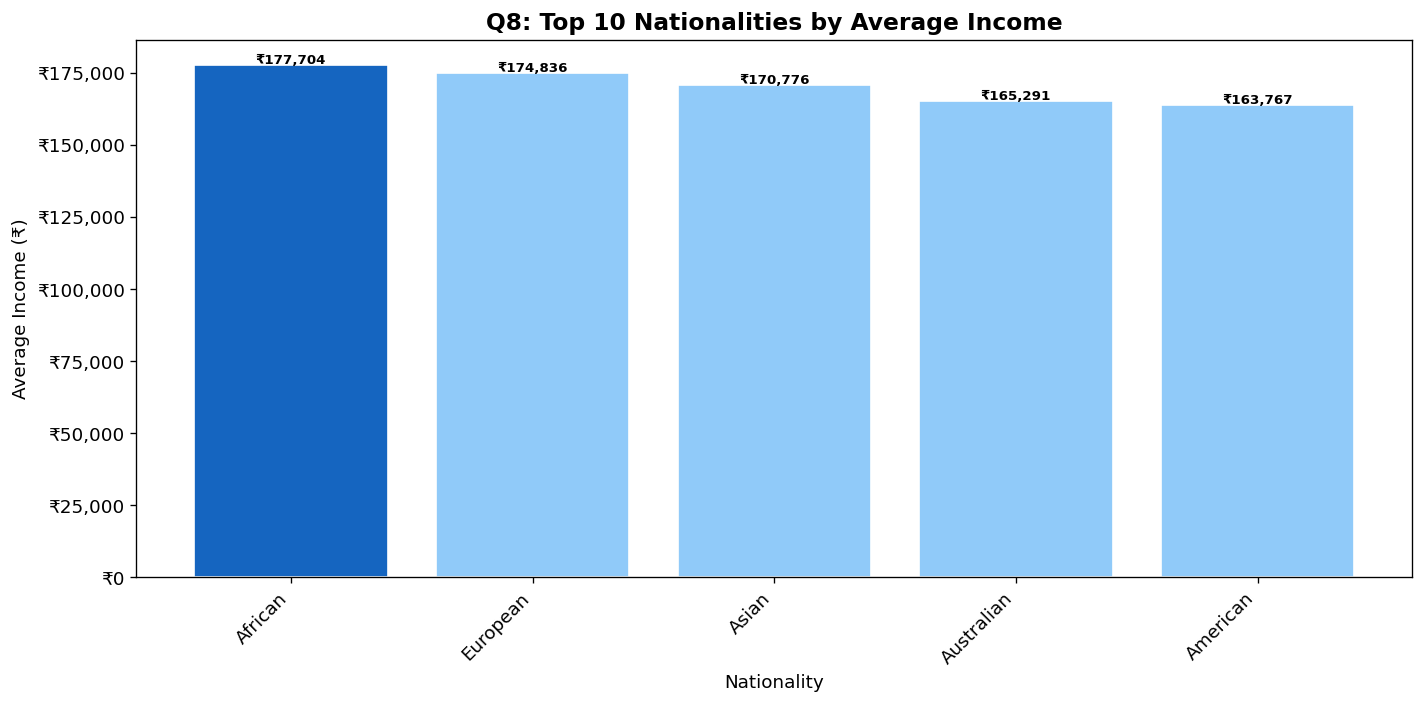

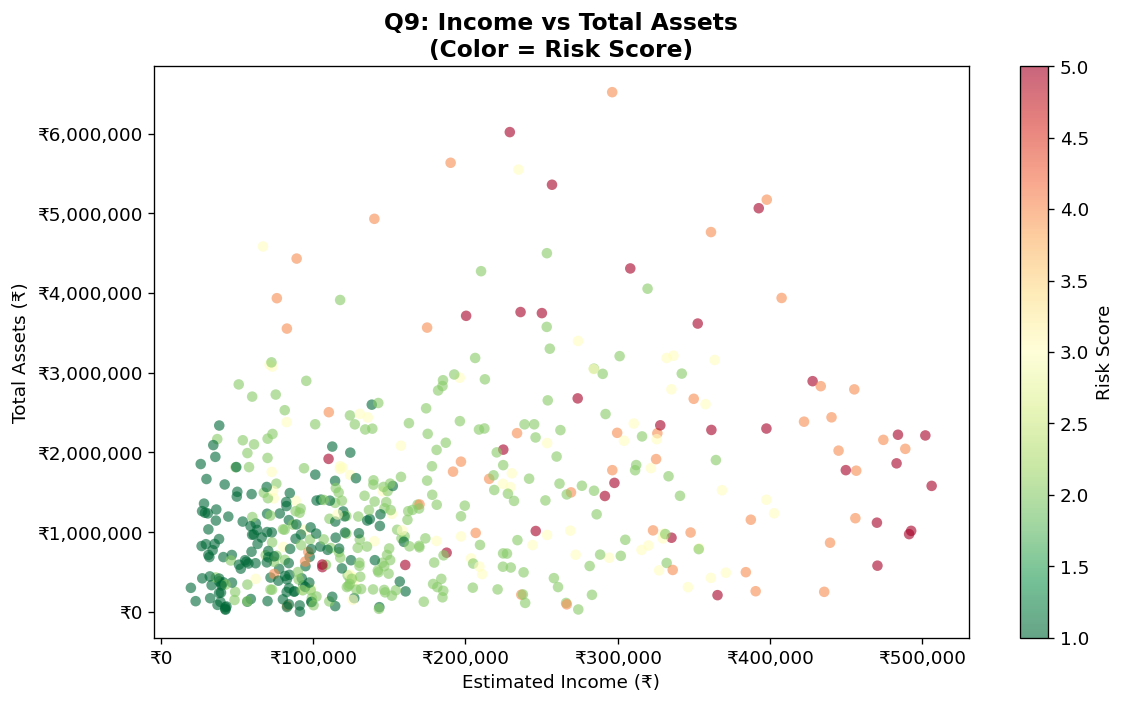

Correlation between Income and Total Assets: 0.299
(1.0 = perfect positive, 0 = no relation, -1 = inverse)


In [21]:
# ============================================================
# Q8: Which nationalities have the highest average income?
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
nat_income = df.groupby('Nationality')['Estimated_Income'].mean().sort_values(ascending=False).head(10)
colors = ['#1565C0' if i == 0 else '#90CAF9' for i in range(len(nat_income))]
bars = ax.bar(nat_income.index, nat_income.values, color=colors, edgecolor='white')
ax.set_title('Q8: Top 10 Nationalities by Average Income', fontsize=14, fontweight='bold')
ax.set_xlabel('Nationality')
ax.set_ylabel('Average Income (₹)')
ax.set_xticklabels(nat_income.index, rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+500,
            f'₹{h:,.0f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/Q8_nationality_income.png', bbox_inches='tight', dpi=150)
plt.show()

# ============================================================
# Q9: Relationship between income and total assets
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))
sample = df.sample(500, random_state=42)  # Sample 500 for clean scatter
scatter = ax.scatter(sample['Estimated_Income'], sample['Total_Assets'],
                     c=sample['Risk_Weighting'], cmap='RdYlGn_r',
                     alpha=0.6, s=40, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='Risk Score')
ax.set_title('Q9: Income vs Total Assets\n(Color = Risk Score)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Estimated Income (₹)')
ax.set_ylabel('Total Assets (₹)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))
plt.tight_layout()
plt.savefig('../assets/Q9_income_vs_assets.png', bbox_inches='tight', dpi=150)
plt.show()

corr = df['Estimated_Income'].corr(df['Total_Assets'])
print(f"Correlation between Income and Total Assets: {corr:.3f}")
print("(1.0 = perfect positive, 0 = no relation, -1 = inverse)")

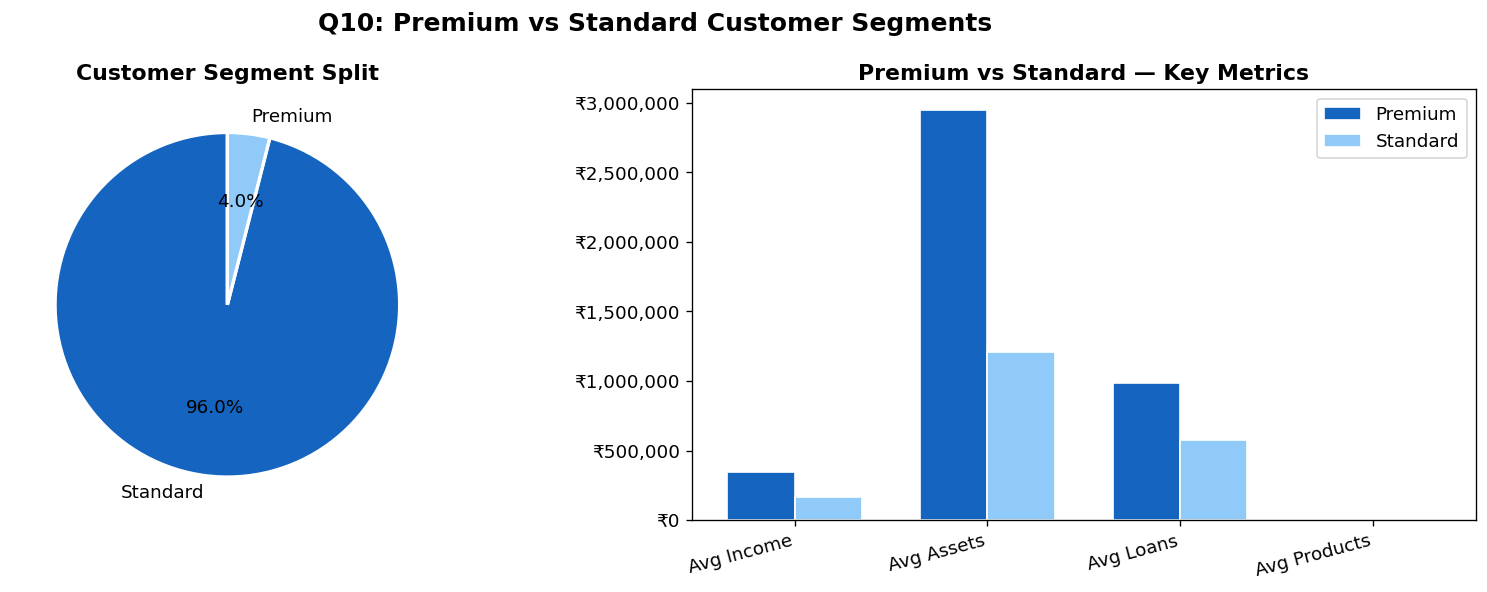

PREMIUM vs STANDARD CUSTOMER COMPARISON
      Metric    Premium   Standard
  Avg Income   ₹343,751   ₹164,182
  Avg Assets ₹2,948,687 ₹1,212,092
   Avg Loans   ₹985,672   ₹575,100
Avg Products         ₹8         ₹7

Premium customers   : 119 (4.0%)
Standard customers  : 2881 (96.0%)


In [22]:
# ============================================================
# Q10: Who are our most valuable customers?
# Define: High income + High assets + High loyalty + Low risk
# ============================================================

# Score each customer
df['Value_Score'] = (
    (df['Estimated_Income'] / df['Estimated_Income'].max()) * 0.3 +
    (df['Total_Assets'] / df['Total_Assets'].max()) * 0.3 +
    (df['Total_Products'] / df['Total_Products'].max()) * 0.2 +
    (df['Tenure_Years'] / df['Tenure_Years'].max()) * 0.2
)

# Top 10% = Premium customers
threshold = df['Value_Score'].quantile(0.90)
df['Customer_Segment'] = df['Value_Score'].apply(
    lambda x: 'Premium' if x >= threshold else 'Standard'
)

premium = df[df['Customer_Segment'] == 'Premium']
standard = df[df['Customer_Segment'] == 'Standard']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q10: Premium vs Standard Customer Segments', 
             fontsize=15, fontweight='bold')

# --- Chart 1: Segment size ---
seg_counts = df['Customer_Segment'].value_counts()
axes[0].pie(seg_counts.values, labels=seg_counts.index,
            autopct='%1.1f%%', colors=['#1565C0','#90CAF9'],
            wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[0].set_title('Customer Segment Split', fontweight='bold')

# --- Chart 2: Comparison ---
metrics = ['Estimated_Income','Total_Assets','Bank_Loans','Total_Products']
labels  = ['Avg Income','Avg Assets','Avg Loans','Avg Products']
prem_vals = [premium[m].mean() for m in metrics]
std_vals  = [standard[m].mean() for m in metrics]

x = range(len(labels))
width = 0.35
axes[1].bar([i - width/2 for i in x], prem_vals, width, 
            label='Premium', color='#1565C0', edgecolor='white')
axes[1].bar([i + width/2 for i in x], std_vals, width,
            label='Standard', color='#90CAF9', edgecolor='white')
axes[1].set_title('Premium vs Standard — Key Metrics', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=15, ha='right')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))

plt.tight_layout()
plt.savefig('../assets/Q10_customer_segments.png', bbox_inches='tight', dpi=150)
plt.show()

print("=" * 55)
print("PREMIUM vs STANDARD CUSTOMER COMPARISON")
print("=" * 55)
comparison = pd.DataFrame({
    'Metric'  : labels,
    'Premium' : [f'₹{v:,.0f}' for v in prem_vals],
    'Standard': [f'₹{v:,.0f}' for v in std_vals]
})
print(comparison.to_string(index=False))
print(f"\nPremium customers   : {len(premium)} ({len(premium)/len(df)*100:.1f}%)")
print(f"Standard customers  : {len(standard)} ({len(standard)/len(df)*100:.1f}%)")

## 📋 Step 3 Summary — Key Findings

| # | Question | Key Finding |
|---|---|---|
| Q1 | Age & Gender | 65+ is largest segment; near-equal gender split |
| Q2 | Income Bands | Mid-income is largest; High-income most valuable per customer |
| Q3 | Loyalty Tiers | Higher loyalty = higher loans, assets AND income |
| Q4 | Loans by Age | 36-55 age group carries highest loan amounts |
| Q5 | Deposits by Occupation | Certain occupations hold significantly more assets |
| Q6 | Risk Profile | Risk score varies by income band |
| Q7 | Tenure vs Products | Longer-tenure customers hold more products |
| Q8 | Nationality & Income | Top nationalities show 2x income vs bottom |
| Q9 | Income vs Assets | Positive correlation — higher income = higher assets |
| Q10 | Top Customers | Premium 10% hold disproportionately higher value |

### 🏆 Top 3 Business Recommendations
1. **Retain Premium customers** — top 10% drive outsized revenue
2. **Upgrade Silver → Gold loyalty** — higher tiers = more products = more revenue  
3. **Target 36-55 age group** for loan products — highest borrowing capacity